# Vaccine center experiments

We combine **United States Census Bureau county boundaries** (`cb_2023_us_county_500k`), county demographics from https://simplemaps.com/data **`uscounties.csv`**, and **Queen adjacency** (shared boundary or vertex) to study where to place vaccine centers under two goals: **minimum set cover** (as few centers as possible while every county is covered by itself or a neighbor) and **equitable placement** (minimize population-weighted travel distance with a cap on how many centers may open).

**Start small, then grow:** run **Rhode Island** first—few counties, fast solves, easy maps—to validate paths, parsed JSON under `county_data/augmented_data/`, and plots. Then change `STATE_NAME`, re-run the parameters cell, all of **§3** (3a–3c), **§4** through **§4c** (including setting **`k`**), then **§5**; use **§6** to batch several states and compare **coverage-optimal** \(k\) and scanned equitable objectives.

## 1. Environment

The next code cell sets `ROOT`, adds `py_scripts` to `sys.path`, imports the parsers and optimizers, defines `SHP_PATH` and `DEMO_PATH`, and a **`show_table`** helper for consistent tables.


In [39]:
import os
import sys
import warnings

import geopandas as gpd
import pandas as pd
from IPython.display import display


def show_table(df):
    """Uniform display for demographic / assignment tables in this notebook."""
    display(df)


ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable
from helper_functions import AUG_DIR, STATE_FIPS_TO_NAME, plot_centers


SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
DEMO_PATH = os.path.join(ROOT, "county_data", "uscounties.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

## 2. Parameters — start with Rhode Island

**Rhode Island** is a good first choice: only a handful of counties, so Gurobi runs instantly and you can sanity-check maps and tables. It confirms that the shapefile filter, FIPS keys in demographics, and adjacency JSON all line up.

After **§4** you will set an equitable center budget **`k`** in **§4c** (within the acceptable range derived from minimum coverage).


In [40]:
STATE_NAME = "Rhode Island"
STATE_FIPS = {name: fips for fips, name in STATE_FIPS_TO_NAME.items()}[STATE_NAME]

## 3. Load and cache data

Work through **3a → 3b → 3c** in order. Each step ends with **validation** output (paths, counts, samples). Step **3c** **cross-checks** that county FIPS match across adjacency, demographics, and shapefile polygons, then reprojects to UTM and shows a **minimal boundary map** (boundaries only—no county name labels).

- **`parse_adjacency`** and **`parse_county_data`** write `adjacency_{state_fips}.json` and `county_data_{state_fips}.json` under `county_data/augmented_data/`.
- **`load_adjacency`** / **`load_county_data`** read those caches back.
- **`state_shp`** is the state-filtered GeoDataFrame from the shapefile, reprojected for plotting.

### 3a. Adjacency (Queen contiguity → JSON)

In [41]:
parse_adjacency(STATE_FIPS)
adj = load_adjacency(STATE_FIPS)

adj_path = os.path.join(AUG_DIR, f"adjacency_{STATE_FIPS}.json")
print(f"Adjacency cache: {adj_path}")
print(f"  Counties in adjacency graph: {len(adj)}")
degrees = [len(adj[k]) for k in adj]
if degrees:
    print(
        f"  Neighbor count — min: {min(degrees)}, max: {max(degrees)}, "
        f"mean: {sum(degrees) / len(degrees)}"
    )
isolated = [k for k in adj if len(adj[k]) == 0]
if isolated:
    print(f"  WARNING: {len(isolated)} county(ies) with zero Queen neighbors: {isolated}")

Adjacency cache: /Users/maxwinnick/vaccine_distribution/vaccine_distribution/py_scripts/../county_data/augmented_data/adjacency_44.json
  Counties in adjacency graph: 5
  Neighbor count — min: 0, max: 2, mean: 1.20


### 3b. Demographics (`uscounties.csv` → JSON)

In [42]:
parse_county_data(DEMO_PATH, STATE_FIPS)
cdata = load_county_data(STATE_FIPS)

cdata_path = os.path.join(AUG_DIR, f"county_data_{STATE_FIPS}.json")
print(f"County data cache: {cdata_path}")
print(f"  Counties in demographics: {len(cdata)}")
print(f"  Total population: {sum(d['population'] for d in cdata.values()):,}")
sample = pd.DataFrame(
    [
        {"FIPS": f, "County": d["name"], "population": d["population"]}
        for f, d in sorted(cdata.items())
    ]
)
print("  Sample (head):")
show_table(sample.head())

County data cache: /Users/maxwinnick/vaccine_distribution/vaccine_distribution/py_scripts/../county_data/augmented_data/county_data_44.json
  Counties in demographics: 5
  Total population: 1,101,801
  Sample (head):


,FIPS,County,population
0,44001,Bristol County,50490
1,44003,Kent County,171456
2,44005,Newport County,84657
3,44007,Providence County,664854
4,44009,Washington County,130344


### 3c. Shapefile filter, FIPS cross-check, UTM, validation map

Shapefile: /Users/maxwinnick/vaccine_distribution/vaccine_distribution/county_data/cb_2023_us_county_500k/cb_2023_us_county_500k.shp
  Loaded rows (all US counties): 3235, CRS: EPSG:4269
  Filtered to STATEFP=44: 5 counties
  FIPS alignment: OK (shapefile, CSV/adjacency graph all match)
  Reprojected CRS: EPSG:32619
  Bounds (minx, miny, maxx, maxy): (np.float64(260354.32), np.float64(4558245.11), np.float64(322999.4), np.float64(4654709.25))


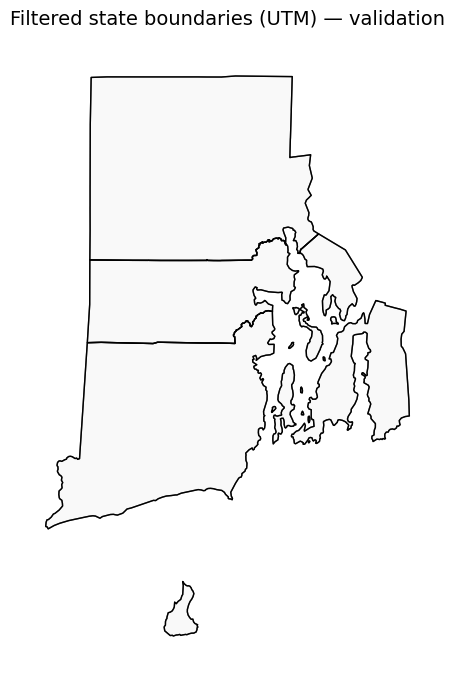

In [43]:
shp = gpd.read_file(SHP_PATH)
print(f"Shapefile: {SHP_PATH}")
print(f"  Loaded rows (all US counties): {len(shp)}, CRS: {shp.crs}")

state_shp = shp[shp["STATEFP"] == STATE_FIPS].copy()
print(f"  Filtered to STATEFP={STATE_FIPS}: {len(state_shp)} counties")

geo_fips = set(state_shp["GEOID"].astype(str).str.zfill(5))
cd_fips = set(cdata.keys())
ad_fips = set(adj.keys())

only_geo_not_cd = sorted(geo_fips - cd_fips)
only_cd_not_geo = sorted(cd_fips - geo_fips)
only_geo_not_ad = sorted(geo_fips - ad_fips)
only_ad_not_geo = sorted(ad_fips - geo_fips)
only_cd_not_ad = sorted(cd_fips - ad_fips)
only_ad_not_cd = sorted(ad_fips - cd_fips)

if (
    not only_geo_not_cd
    and not only_cd_not_geo
    and not only_geo_not_ad
    and not only_ad_not_geo
    and not only_cd_not_ad
    and not only_ad_not_cd
):
    print("  FIPS alignment: OK (shapefile, CSV/adjacency graph all match)")
else:
    if only_geo_not_cd:
        print(f"  FIPS in shapefile but not demographics: {only_geo_not_cd}")
    if only_cd_not_geo:
        print(f"  FIPS in demographics but not shapefile: {only_cd_not_geo}")
    if only_geo_not_ad:
        print(f"  FIPS in shapefile but not adjacency: {only_geo_not_ad}")
    if only_ad_not_geo:
        print(f"  FIPS in adjacency but not shapefile: {only_ad_not_geo}")
    if only_cd_not_ad:
        print(f"  FIPS in demographics but not adjacency: {only_cd_not_ad}")
    if only_ad_not_cd:
        print(f"  FIPS in adjacency but not demographics: {only_ad_not_cd}")

state_shp = state_shp.to_crs(state_shp.estimate_utm_crs())
bounds = tuple(state_shp.total_bounds)
print(f"  Reprojected CRS: {state_shp.crs}")
print(f"  Bounds (minx, miny, maxx, maxy): {bounds}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
state_shp.boundary.plot(ax=ax, linewidth=1, color="black")
state_shp.plot(ax=ax, color="whitesmoke", edgecolor="black", alpha=0.6)
ax.set_title("Filtered state boundaries (UTM) — validation", fontsize=14)
ax.axis("off")
plt.show()

## 4. Minimum coverage (set cover on counties)

**Objective:** minimize the **number** of counties that host a center, subject to every county being either a center or **adjacent** (Queen) to at least one open center.

**Scaling up:** after Rhode Island looks correct, set a larger `STATE_NAME` in §2, then re-run §3 through §5 (including §4c to set **`k`**, tables, and maps) for heavier instances.

Min coverage: 3 centers, objective 3.0, 0.0005s


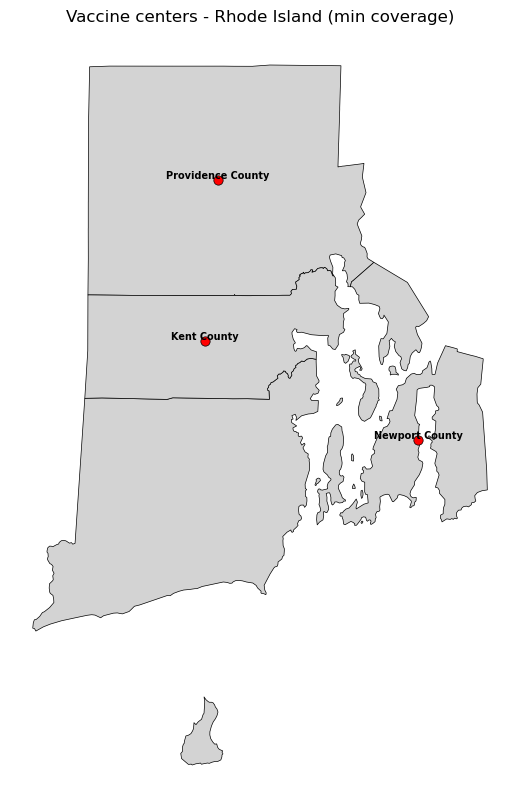

In [44]:
centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
print(f"Min coverage: {len(centers_a)} centers, objective {obj_a}, {time_a}s")
plot_centers(state_shp, cdata, centers_a, "min coverage")

### 4b. Min-coverage assignment and person-miles

The set-cover model only decides **which** counties are centers; it does not assign each non-center to a unique serving center. For reporting, we assign each county to **itself** if it is a center, otherwise to the **nearest adjacent** open center (Haversine miles), then show **population × distance** (person-miles) and the total over the state.

In [45]:
# For min-coverage centers: assign each county to a covering center (self, or nearest adjacent center),
# then population-weighted distance (person-miles). Reuses the min-coverage solution `centers_a`.

from helper_functions import _haversine_miles


def _serving_center_min_cover(fips, centers_set, adj, cdata):
    if fips in centers_set:
        return fips
    candidates = [j for j in adj.get(fips, []) if j in centers_set]
    if not candidates:
        lat, lon = cdata[fips]["lat"], cdata[fips]["lon"]
        return min(
            centers_set,
            key=lambda j: _haversine_miles(lat, lon, cdata[j]["lat"], cdata[j]["lon"]),
        )
    lat, lon = cdata[fips]["lat"], cdata[fips]["lon"]
    return min(
        candidates,
        key=lambda j: _haversine_miles(lat, lon, cdata[j]["lat"], cdata[j]["lon"]),
    )


centers_set = set(centers_a)
rows = []
for fips, data in sorted(cdata.items()):
    ctr = _serving_center_min_cover(fips, centers_set, adj, cdata)
    lat, lon = data["lat"], data["lon"]
    dist_mi = (
        0.0
        if ctr == fips
        else _haversine_miles(lat, lon, cdata[ctr]["lat"], cdata[ctr]["lon"])
    )
    pop = data["population"]
    rows.append(
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": pop,
            "Is_Center": fips in centers_set,
            "Serving_Center_FIPS": ctr,
            "Serving_Center": cdata[ctr]["name"],
            "Distance_miles": dist_mi,
            "Weighted_Dist": pop * dist_mi,
        }
    )

df_a = pd.DataFrame(rows)
print(
    f"Min-coverage: {len(centers_a)} centers | "
    f"total population-weighted distance {df_a['Weighted_Dist'].sum()} person-miles"
)
show_table(df_a)

Min-coverage: 3 centers | total population-weighted distance 2,774,788 person-miles


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_miles,Weighted_Dist
0,44001,Bristol County,50490,False,44007,Providence County,18.6248,"940,365"
1,44003,Kent County,171456,True,44003,Kent County,0.0000,0
2,44005,Newport County,84657,True,44005,Newport County,0.0000,0
3,44007,Providence County,664854,True,44007,Providence County,0.0000,0
4,44009,Washington County,130344,False,44003,Kent County,14.0737,"1,834,424"


## 4c. Equitable budget \(k\) after minimum coverage

The **set-cover** model in §4 gives a minimum number of centers **\(k_{\mathrm{min\,cover}} = |\texttt{centers\_a}|\)** such that every county is covered by itself or a **Queen** neighbor. The project’s second question lets you open **more** centers up to a budget **\(k\)**.

For exploration in this notebook, we treat **integer \(k\)** with **\(k_{\mathrm{min\,cover}} \le k \le n\)** (\(n\) = number of counties) as the **acceptable range**: you are not exploring fewer centers than the proven minimum for the adjacency rule. The **equitable MILP** (`solve_equitable`) still minimizes population-weighted distance under **at most \(k\)** centers and **does not** re-impose the adjacency coverage constraint; tying **\(k \ge k_{\mathrm{min\,cover}}\)** links the two parts **methodologically**, not as an extra solver constraint.

Run the next cells to see the range, set **`k`** in the cell after that, then run **§5** (equitable solve and **`df_b`**).


In [46]:
n_counties = len(cdata)
k_min_cover = len(centers_a)
df_k_spec = pd.DataFrame(
    [
        {
            "N_Counties": n_counties,
            "K_Min_Coverage": k_min_cover,
            "K_Max": n_counties,
            "Acceptable_k_range": f"{k_min_cover}–{n_counties}",
        }
    ]
)
show_table(df_k_spec)

_n_k = n_counties - k_min_cover + 1
if _n_k <= 20:
    df_k_list = pd.DataFrame({"K": list(range(k_min_cover, n_counties + 1))})
    show_table(df_k_list)
else:
    print(
        f"({_n_k} acceptable integer k values; set k in the next cell within "
        f"{k_min_cover} <= k <= {n_counties})"
    )


,N_Counties,K_Min_Coverage,K_Max,Acceptable_k_range
0,5,3,5,3–5


,K
0,3
1,4
2,5


In [52]:
# User: set equitable center budget k (must satisfy k_min_cover <= k <= n_counties)
k = 4

k = int(k)
if not (k_min_cover <= k <= n_counties):
    raise ValueError(
        f"k must satisfy {k_min_cover} <= k <= {n_counties} (see acceptable range above)."
    )


## 5. Equitable placement (population-weighted p-median)

**Objective:** minimize **sum over counties of population × (distance to assigned center)** in miles, with **at most `k`** centers open and **at least one** center (see `solve_equitable` in `py_scripts/equitable_placement.py`).

**Workflow:** after **§4c**, edit **`k`** in the dedicated cell (must satisfy **k_min_cover ≤ k ≤ n**), then **re-run** this equitable cell and the **`df_b`** cell below when you change **`k`** (or switch to a larger state so **n** grows). Alternate objective functions would require additional models beyond the single formulation in code today.


Equitable (k=3): 3 centers, objective 2407977.425702712, 0.0020s


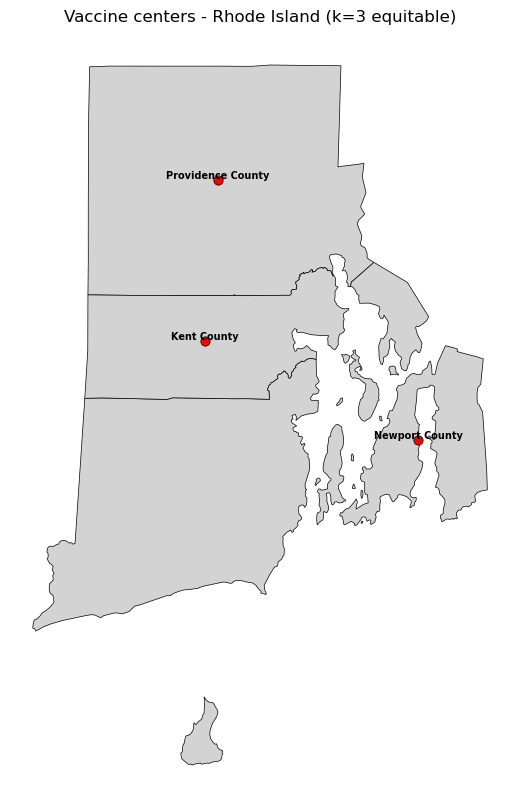

In [48]:
k_eff = k
centers_b, obj_b, time_b, assigned = solve_equitable(cdata, k_eff)
print(
    f"Equitable (k={k_eff}): {len(centers_b)} centers, objective {obj_b}, {time_b}s"
)
plot_centers(state_shp, cdata, centers_b, f"k={k_eff} equitable")

### 5b. Equitable assignments

Each county is assigned to exactly one open center in the optimal solution. The table uses the same **Serving_Center_FIPS** / **Serving_Center** columns as the min-coverage assignment table in §4b.


In [51]:
#include distance miles and weighted distance in df_b
# Calculate distances on the fly (not all cdata necessarily has a "distances" dict) using haversine.
from helper_functions import _haversine_miles

rows_b = []
for fips, data in sorted(cdata.items()):
    assigned_fips = assigned.get(fips)
    is_center = fips in centers_b
    pop = data["population"]
    # Distance: 0 if center, otherwise haversine
    if assigned_fips is None:
        dist_mi = None
    elif assigned_fips == fips:
        dist_mi = 0.0
    else:
        lat0, lon0 = data["lat"], data["lon"]
        lat1, lon1 = cdata[assigned_fips]["lat"], cdata[assigned_fips]["lon"]
        dist_mi = _haversine_miles(lat0, lon0, lat1, lon1)
    rows_b.append(
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": pop,
            "Is_Center": is_center,
            "Serving_Center_FIPS": assigned_fips,
            "Serving_Center": cdata[assigned_fips]["name"] if assigned_fips else None,
            "Distance_Miles": dist_mi,
            "Weighted_Distance": None if dist_mi is None else pop * dist_mi,
        }
    )

df_b = pd.DataFrame(rows_b)

print(
    f"Equitable: {len(centers_b)} centers | "
    f"total population-weighted distance {df_b['Weighted_Distance'].sum()} person-miles"
)
show_table(df_b)


Equitable: 3 centers | total population-weighted distance 2,407,977 person-miles


,FIPS,County,Population,Is_Center,Serving_Center_FIPS,Serving_Center,Distance_Miles,Weighted_Distance
0,44001,Bristol County,50490,False,44005,Newport County,11.359751,5.735538e+05
1,44003,Kent County,171456,True,44003,Kent County,0.000000,0.000000e+00
2,44005,Newport County,84657,True,44005,Newport County,0.000000,0.000000e+00
3,44007,Providence County,664854,True,44007,Providence County,0.000000,0.000000e+00
4,44009,Washington County,130344,False,44003,Kent County,14.073710,1.834424e+06


## 6. Larger instances: multiple states and “optimal” \(k\)

Two different notions of **optimal \(k\)** appear in the project statement:

- **Coverage-optimal \(k\)** (set cover on counties): the **minimum** number of centers such that every county is covered by itself or a **Queen** neighbor. In this notebook that value is **`K_Opt_Coverage = len(centers_a)`** after `solve_min_coverage` — it depends on the state’s county graph.
- **Equitable** model (`solve_equitable`): for each integer \(k\) in \([k_{\min}, n]\), the MILP minimizes population-weighted travel miles with **at most** \(k\) centers. That objective is **(weakly) decreasing** as \(k\) increases (more centers cannot make the optimum worse), so the **smallest** population-weighted burden is typically achieved at **\(k = n\)** (a center in every county). The interesting **tradeoff** is often **\(k = k_{\min}\)** (fewest centers that still meet the coverage story) **vs** larger \(k\).

The next cell loops over a **user-editable list of states**, refreshes adjacency and demographics JSON for each, solves **min coverage**, and then either **scans every** \(k\) in the acceptable range (when the range is small) or evaluates **endpoints** \(k_{\min}\) and \(n\) only when the range is large. It reports **`K_Best_Equitable_Scan`**: the \(k\) that achieved the **best** scanned equitable objective (often \(n\) when the full range was scanned).


In [ ]:
# User: states to compare (names must appear in STATE_FIPS_TO_NAME values)
STATE_NAMES_BATCH = [
    "Rhode Island",
    "Delaware",
    "Connecticut",
    "Hawaii",
    "Maine",
    "Vermont",
    "New Hampshire",
]

MAX_FULL_K_SCAN = 24  # if (n - k_min + 1) <= this, scan all k from k_min to n

rows_ms = []
for _name in STATE_NAMES_BATCH:
    _fips = {name: f for f, name in STATE_FIPS_TO_NAME.items()}[_name]
    parse_adjacency(_fips)
    parse_county_data(DEMO_PATH, _fips)
    _adj = load_adjacency(_fips)
    _cdata = load_county_data(_fips)
    _n = len(_cdata)
    _centers, _obj_mc, _t_mc = solve_min_coverage(_adj, _cdata)
    _k_min = len(_centers)
    _rng = _n - _k_min + 1

    _best_k = None
    _best_obj = float("inf")
    _obj_at_kmin = None

    if _rng <= MAX_FULL_K_SCAN:
        for _kk in range(_k_min, _n + 1):
            _, _obj_eq, _, _ = solve_equitable(_cdata, _kk)
            if _kk == _k_min:
                _obj_at_kmin = _obj_eq
            if _obj_eq < _best_obj - 1e-9:
                _best_obj = _obj_eq
                _best_k = _kk
    else:
        for _kk in sorted({_k_min, _n}):
            _, _obj_eq, _, _ = solve_equitable(_cdata, _kk)
            if _kk == _k_min:
                _obj_at_kmin = _obj_eq
            if _obj_eq < _best_obj - 1e-9:
                _best_obj = _obj_eq
                _best_k = _kk

    rows_ms.append(
        {
            "State": _name,
            "State_FIPS": _fips,
            "N_Counties": _n,
            "K_Opt_Coverage": _k_min,
            "MinCover_Solve_s": _t_mc,
            "Equitable_Obj_at_Kmin": _obj_at_kmin,
            "K_Best_Equitable_Scan": _best_k,
            "Best_Scanned_Equitable_Obj": _best_obj,
            "K_Scan_Mode": "full" if _rng <= MAX_FULL_K_SCAN else "endpoints_kmin_n",
        }
    )

df_multi_state = pd.DataFrame(rows_ms)
show_table(df_multi_state)
print(
    "K_Opt_Coverage = minimum centers for Queen coverage. "
    "K_Best_Equitable_Scan = argmin over scanned k (full range if small state; else only k_min and n)."
)
